# Auswertung zur Diplomarbeit

## Import der notwendigen Packages

In [29]:
%matplotlib inline

from pathlib import Path
import contextily as cx
import geopandas as gpd
import pandas as pd
import shapely.geometry as shp
from matplotlib import pyplot as plt
from matplotlib import gridspec
import geodatasets
import numpy as np

import diplomarbeit as da

from sklearn.linear_model import LinearRegression

import seaborn as sns

import osmnx as ox

import matplot2tikz

## Definition von Variablen und Pfaden

In [30]:
RESULTS_DIR = Path('./results')  # TODO: Make LaTeX-Picture directory for Production

plt.rc('font', family='serif', size=11)
plt.rc('text', usetex=True)

cm = 1/2.54

## Laden des Datasets

In [31]:
data=gpd.read_file(da.DATA_DICT / 'building_data.json').dropna(axis='index')
data

,line_name,line_number,from,to,distance,curvature,height_up,height_down,gauge,gtfs_first_stop_name,...,city,Country,ISO3166,Stadt,machine_readable,OSM-Name,Buffer_Width,region,rho_b,geometry
1,Tram 12: Amsterdam Amstelstation => Amsterdam ...,12,"Amsterdam, Amstelstation","Amsterdam, Centraal Station",7.236546,296.964916,7.462124,7.876686,1435.0,"Amsterdam, Amstelstation",...,amsterdam,Niederlande,NL,Amsterdam,amsterdam,"Amsterdam, Netherlands",60.273777,BeNeLux,0.330303,"LINESTRING (4.91789 52.34744, 4.918 52.34726, ..."
2,Tram 12: Amsterdam Centraal Station => Amsterd...,12,"Amsterdam, Centraal Station","Amsterdam, Amstelstation",7.045116,282.208086,8.090711,7.664884,1435.0,"Amsterdam, Centraal Station",...,amsterdam,Niederlande,NL,Amsterdam,amsterdam,"Amsterdam, Netherlands",60.273777,BeNeLux,0.332516,"LINESTRING (4.89929 52.37832, 4.89936 52.37825..."
3,Tram 13: Amsterdam Geuzenveld => Amsterdam Zou...,13,"Amsterdam, Lambertus Zijlplein","Amsterdam, Zoutkeetsgracht",8.317058,182.758543,7.334325,7.093855,1435.0,"Amsterdam, Lambertus Zijlplein",...,amsterdam,Niederlande,NL,Amsterdam,amsterdam,"Amsterdam, Netherlands",60.273777,BeNeLux,0.239930,"LINESTRING (4.80291 52.37728, 4.8032 52.37724,..."
4,Tram 13: Amsterdam Zoutkeetsgracht => Amsterda...,13,"Amsterdam, Zoutkeetsgracht","Amsterdam, Lambertus Zijlplein",8.299482,202.032577,7.470346,7.590835,1435.0,"Amsterdam, Zoutkeetsgracht",...,amsterdam,Niederlande,NL,Amsterdam,amsterdam,"Amsterdam, Netherlands",60.273777,BeNeLux,0.234033,"LINESTRING (4.88514 52.38808, 4.8851 52.38809,..."
5,Tram 14: Amsterdam Centraal Station => Amsterd...,14,"Amsterdam, Centraal Station","Amsterdam, Javaplein",5.048854,263.381860,10.695496,10.101302,1435.0,"Amsterdam, Centraal Station",...,amsterdam,Niederlande,NL,Amsterdam,amsterdam,"Amsterdam, Netherlands",60.273777,BeNeLux,0.322985,"LINESTRING (4.90036 52.37785, 4.90029 52.37786..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1592,Tram 7: Wollishoferplatz → Bahnhof Stettbach,7,"Zürich, Wollishoferplatz","Zürich, Bahnhof Stettbach",12.610090,201.312460,21.411424,22.759551,1000.0,"Zürich, Wollishoferplatz",...,zuerich,Schweiz,CH,Zürich,zuerich,"Zurich, Switzerland",83.614645,DACH,0.251457,"LINESTRING (8.53074 47.33833, 8.5308 47.33831,..."
1597,Tram 9: Heuried → Hirzenbach,9,"Zürich, Heuried","Zürich, Hirzenbach",12.081617,197.018987,19.368268,19.285498,1000.0,"Zürich, Heuried",...,zuerich,Schweiz,CH,Zürich,zuerich,"Zurich, Switzerland",83.614645,DACH,0.248528,"LINESTRING (8.50618 47.36943, 8.50607 47.36942..."
1598,Tram 9: Hirzenbach → Heuried,9,"Zürich, Hirzenbach","Zürich, Heuried",11.937945,181.472686,19.601363,19.685130,1000.0,"Zürich, Hirzenbach",...,zuerich,Schweiz,CH,Zürich,zuerich,"Zurich, Switzerland",83.614645,DACH,0.249556,"LINESTRING (8.59101 47.40316, 8.59102 47.40314..."
1599,Tram 9: Hirzenbach → Triemli,9,"Zürich, Hirzenbach","Zürich, Triemli",12.784511,178.049878,20.884647,18.616277,1000.0,"Zürich, Hirzenbach",...,zuerich,Schweiz,CH,Zürich,zuerich,"Zurich, Switzerland",83.614645,DACH,0.246638,"LINESTRING (8.59101 47.40316, 8.59102 47.40314..."


### Gruppieren der Städte

In [32]:
# TODO: Gewichteter Mittelwert der Geschwindigkeiten!

def weighted_average(data:pd.DataFrame, value, weight):
    val = data[value]
    wt = data[weight]
    return (val * wt).sum() / wt.sum()


In [33]:
agg_func = {'distance': ['mean', 'sum'],
            #'trip_speed': ['mean'],
            'number_trips': ['sum'],
            'avg_dist': ['mean'],
            'rho_b': ['mean'],
            'machine_readable': ['count'],
            'Stadt': 'first',
            'ISO3166': 'first',
            'gauge': 'first',
           'region':'first'}
df_cities_grouped = data[['Stadt', 'distance', 'trip_speed', 'number_trips', 'avg_dist', 'rho_b', 'gauge', 'ISO3166',
                    'machine_readable', 'region']].groupby(by=['ISO3166', 'Stadt']).aggregate(func=agg_func)
df_cities_grouped['trip_speeds_new']=data.groupby(['ISO3166', 'Stadt']).apply(weighted_average, 'trip_speed', 'number_trips')
df_cities_grouped.rename(columns={'machine_readable': 'Anzahl Relationen'}, inplace=True)
df_cities_grouped.rename_axis(['ISO3166', 'Stadt']).reset_index(inplace=True)
df_cities_grouped.columns = df_cities_grouped.columns.droplevel(1)
df_cities_grouped

distance    distance  number_trips  \
ISO3166 Stadt                                                          
AT      Graz                      8.671587  138.745392       26079.0   
        Innsbruck                11.991356  131.904912        3407.0   
        Linz                     13.335696  160.028358        3633.0   
        Wien                      7.803543  515.033817       80703.0   
AU      Melbourne                14.537361  625.106509       37889.0   
BE      Antwerpen                10.226315  224.978935       18976.0   
        Brüssel                   9.728008  233.472199        8814.0   
        Gent                      8.849096   88.490957        6124.0   
BG      Sofia                     9.351166  224.427995        3750.0   
CA      Toronto                  10.456632  125.479585        5938.0   
CH      Zürich                    9.644979  135.029708        7764.0   
CZ      Prag                     15.640986  969.741123        7067.0   
DE      Berlin                   10.813977  475.814975       11334.0   
        Brandenburg a. d. Havel   8.120737   32.482947         746.0   
        Freiburg                  8.685922   52.115531        2492.0   
        Köln                     19.670689  747.486199       16476.0   
        München                   8.734260  279.496331        5628.0   
        Potsdam                   8.496155  237.892342        1681.0   
        Stuttgart                16.065630  337.378239        3751.0   
        Ulm                      10.080376   40.321502        1434.0   
FI      Helsinki                  9.502415  247.062779       27946.0   
FR      Bordeaux                 16.402288  295.241180       15519.0   
        Lyon                     10.700203  192.603654       10684.0   
HR      Zagreb                   10.720903  364.510698       20557.0   
HU      Budapest                  9.392749  610.528710       39721.0   
IT      Mailand                   8.657722  121.208104        3910.0   
        Rom                       7.420319  103.884471        3936.0   
        Turin                     9.100353   36.401414        2230.0   
LV      Riga                     11.835803  118.358025         753.0   
NL      Amsterdam                 9.256029  259.168810       19105.0   
        Den Haag                 15.047153  315.990211        9489.0   
        Rotterdam                11.227226  157.181159        2398.0   
PL      Katowice                 10.132915  445.848269        1092.0   
        Warschau                 14.814819  933.333572       42744.0   
RO      Bukarest                  9.122874  200.703236        8023.0   
RU      Sankt Petersburg         10.712430  696.307937       12003.0   
SE      Göteborg                 16.863458  404.722981       23470.0   
UA      Lviv                      7.566589   45.399531        1046.0   
UK      Manchester               22.873098  343.096477        9929.0   
US      Portland                  8.185928   32.743714        1338.0   
        San Francisco            11.568248  115.682475        2828.0   

                                    avg_dist     rho_b  Anzahl Relationen  \
ISO3166 Stadt                                                               
AT      Graz                      370.220473  0.324247                 16   
        Innsbruck                 553.844794  0.208517                 11   
        Linz                      434.255996  0.225400                 12   
        Wien                      408.942623  0.315631                 66   
AU      Melbourne                 305.543480  0.234671                 43   
BE      Antwerpen                 501.375294  0.346852                 22   
        Brüssel                   505.625998  0.232133                 24   
        Gent                      413.080336  0.349982                 10   
BG      Sofia                     458.925046  0.219031                 24   
CA      Toronto                   282.463094  0.289672                 12   
CH      Züric

## Auswertung



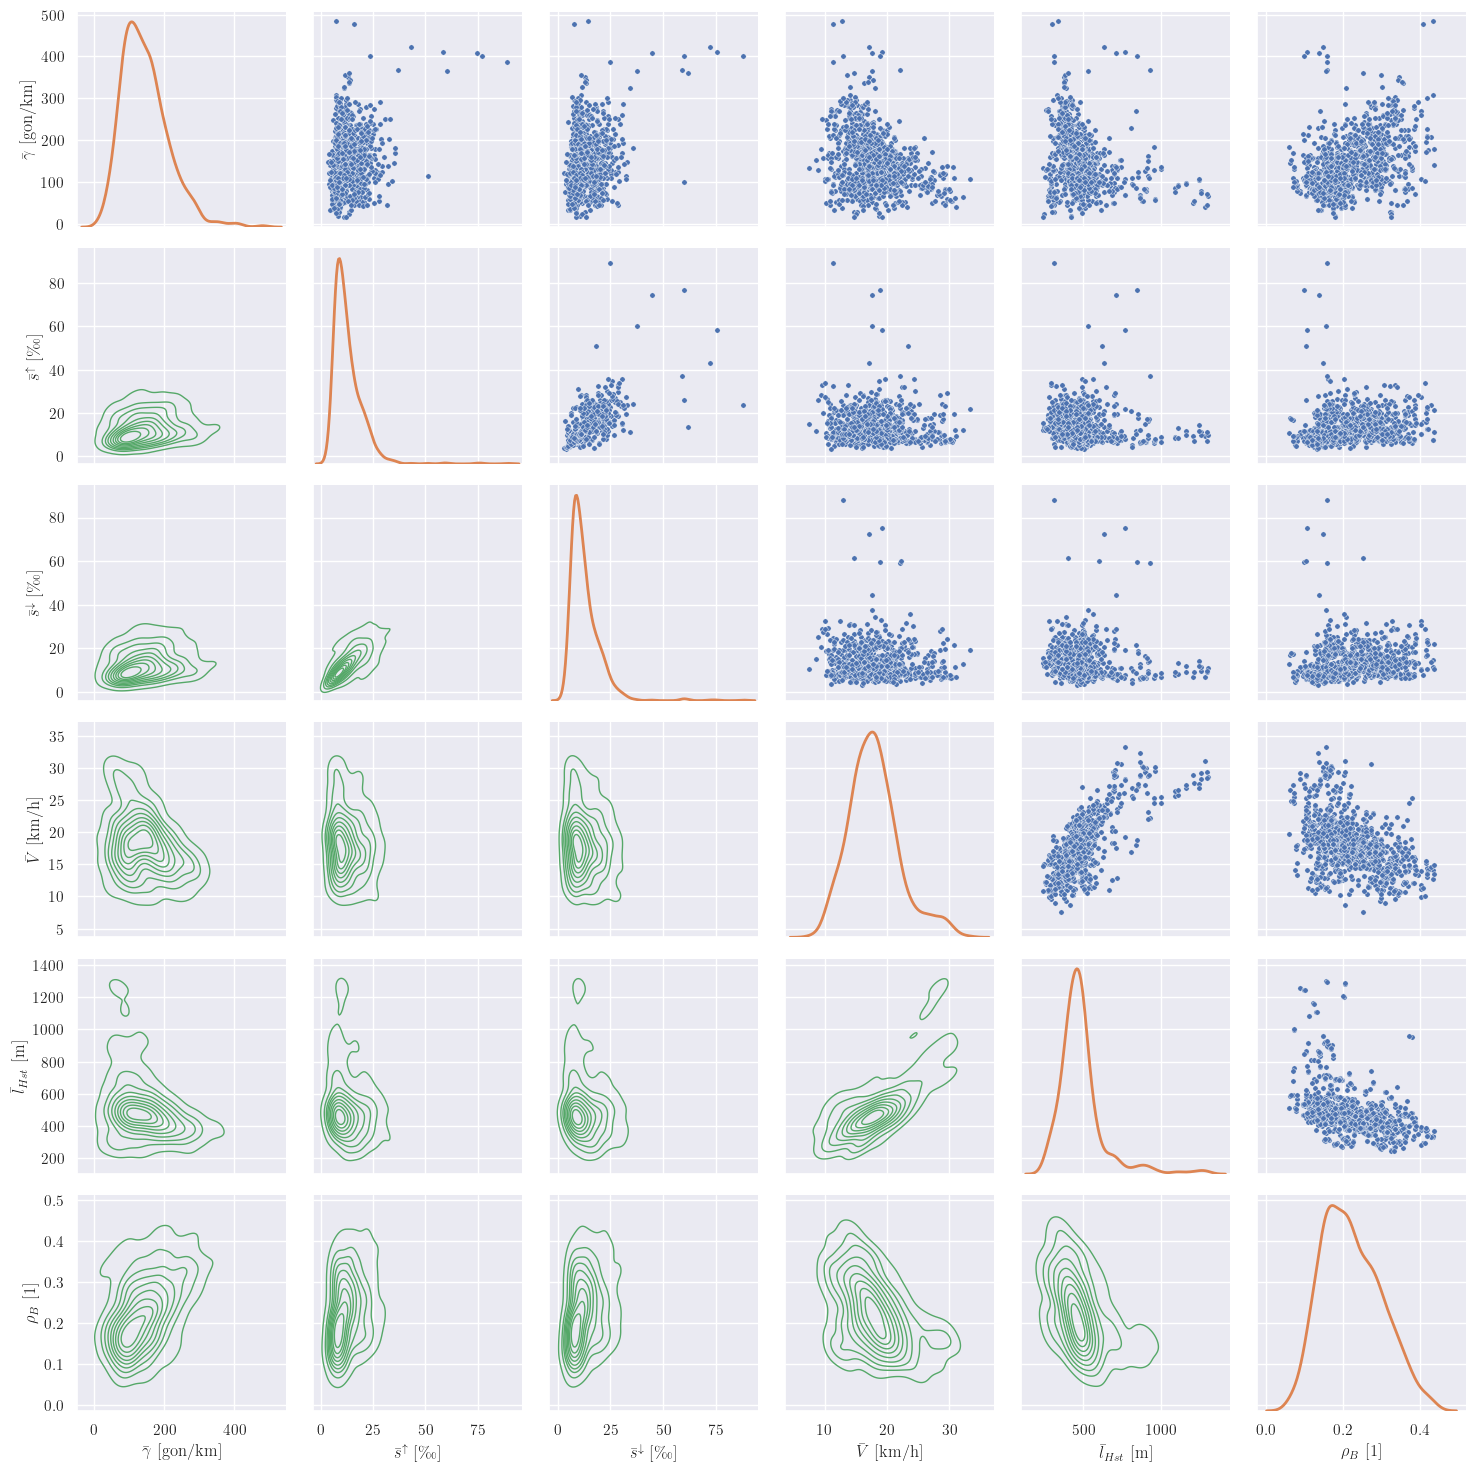

In [34]:
data_tex = data[['curvature', 'height_up', 'height_down', 'trip_speed', 'avg_dist', 'rho_b']].rename(
        columns=da.COLUMN_NAMES_TEX)

g = sns.PairGrid(data=data_tex.dropna(axis=0), diag_sharey=False)
g.map_upper(sns.scatterplot, s=15, color='C0')
g.map_diag(sns.kdeplot, lw=2, color='C1')
g.map_lower(sns.kdeplot, linewidths=1, color='C2')

### Violinplots der Parameter

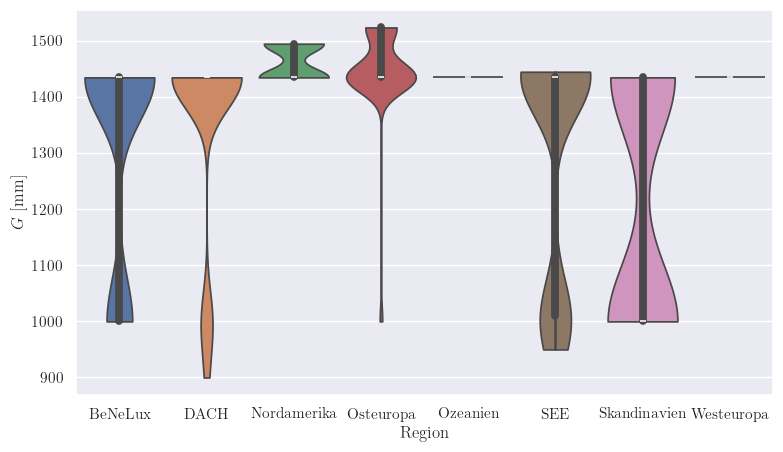

In [35]:
sns.set_theme()
plt.rc('font', family='serif', size=11)
plt.rc('text', usetex=True)

order=list(data['region'].unique())
order.sort()

for value in da.COLUMN_NAMES_DE:
    #value='avg_dist'
    filename=value+'.png'
    filename_tex=value+'.tex'

    fig, ax = plt.subplots(1,1, figsize=(9,5))
    sns.violinplot(data=data.dropna(axis='index'), y=value, x='region', hue='region', cut=0, hue_order=order, order=order, ax=ax)
    plt.ylabel(da.COLUMN_NAMES_TEX[value])
    plt.xlabel('Region')


    plt.savefig(RESULTS_DIR / 'Verteilungen' / filename, dpi=600)

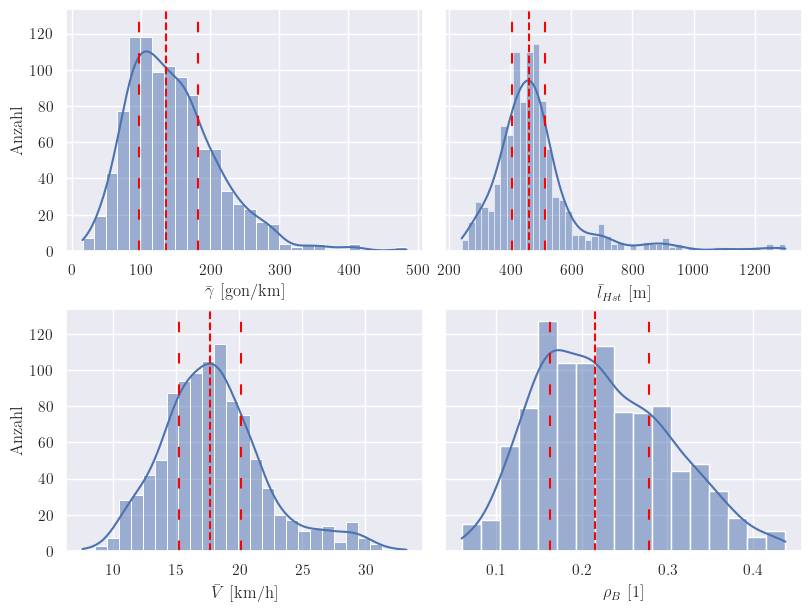

In [36]:
val_list=list(da.COLUMN_NAMES_TEX.keys())
val_list.pop(val_list.index('gauge'))
val_list.pop(val_list.index('height_up'))
val_list.pop(val_list.index('height_down'))
n = len(val_list)
ncols = int(np.ceil(np.sqrt(n)))
nrows = int(np.ceil(n / ncols))
figsize = (ncols * 4, nrows * 3)
fig, axes=plt.subplots(nrows, ncols, figsize=figsize, layout='constrained', sharey=True)

for ax, value in zip(axes.flat, val_list):
    sns.histplot(data, x=value,ax=ax, kde=True)
    ax.axvline(x=data[value].median(), color='red', ls='--')
    ax.axvline(x=data[value].quantile(0.25),
                color='red',
               ls=(0, (5, 10)))
    ax.axvline(x=data[value].quantile(0.75),
                color='red',
              ls=(0, (5, 10)))
    ax.set_xlabel(da.COLUMN_NAMES_TEX[value])
    ax.set_ylabel('Anzahl')

In [37]:
data[(data['height_up']>data['height_up'].quantile(0.95))].dropna(axis='index')[['Stadt', 'line_name','height_up']].sort_values(by='height_up', ascending=False) #& (data['region']=='Westeuropa')

,Stadt,line_name,height_up
700,Linz,50: Hauptplatz - Pöstlingberg,89.217482
540,Innsbruck,Tram STB: Innsbruck => Fulpmes,76.964968
541,Innsbruck,Tram STB: Innsbruck => Mutters,74.662570
538,Innsbruck,Tram 6: Innsbruck Mühlauer Brücke => Igls,60.177657
539,Innsbruck,Tram STB: Fulpmes => Innsbruck,58.443845
1528,Zagreb,Tram 15: Mihaljevac => Gračansko Dolje,51.101259
542,Innsbruck,Tram STB: Mutters => Innsbruck,43.213692
537,Innsbruck,Tram 6: Igls Bahnhof => Innsbruck Bergisel,36.968037
1302,Stuttgart,U15: Stammheim => Ruhbank (Fernsehturm),35.702875
316,Budapest,56A => Budagyöngye,35.565188


### Violinplot Höhen

In [38]:
df_height=data.dropna(axis=1)
df_height = df_height.melt(value_vars=['height_up', 'height_down'], id_vars=['line_name', 'region', 'Stadt'])
df_height

,line_name,region,Stadt,variable,value
0,Tram 12: Amsterdam Amstelstation => Amsterdam ...,BeNeLux,Amsterdam,height_up,7.462124
1,Tram 12: Amsterdam Centraal Station => Amsterd...,BeNeLux,Amsterdam,height_up,8.090711
2,Tram 13: Amsterdam Geuzenveld => Amsterdam Zou...,BeNeLux,Amsterdam,height_up,7.334325
3,Tram 13: Amsterdam Zoutkeetsgracht => Amsterda...,BeNeLux,Amsterdam,height_up,7.470346
4,Tram 14: Amsterdam Centraal Station => Amsterd...,BeNeLux,Amsterdam,height_up,10.695496
...,...,...,...,...,...
2019,Tram 7: Wollishoferplatz → Bahnhof Stettbach,DACH,Zürich,height_down,22.759551
2020,Tram 9: Heuried → Hirzenbach,DACH,Zürich,height_down,19.285498
2021,Tram 9: Hirzenbach → Heuried,DACH,Zürich,height_down,19.685130
2022,Tram 9: Hirzenbach → Triemli,DACH,Zürich,height_down,18.616277


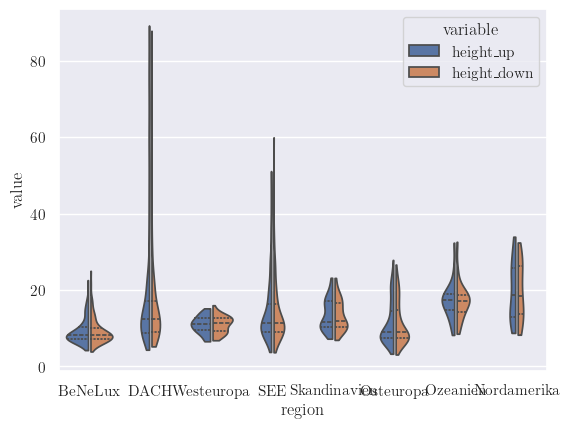

In [39]:
fig, ax = plt.subplots(1,1, figsize=(6.3,4.7))
sns.violinplot(data= df_height,
               x='region',
               y='value',
               hue= 'variable',
               split= True,
               ax= ax,
               inner= 'quart',
               gap= 0.1,
               cut= 0,
               common_norm= True)

### Verteilung der Spurweiten auf die Regionen

In [40]:
df_draw=df_cities_grouped.groupby(by=['region','gauge'],observed=False).aggregate(func={'Stadt':'count'})
result = df_draw.unstack('region')
result=result.droplevel(0, axis=1)

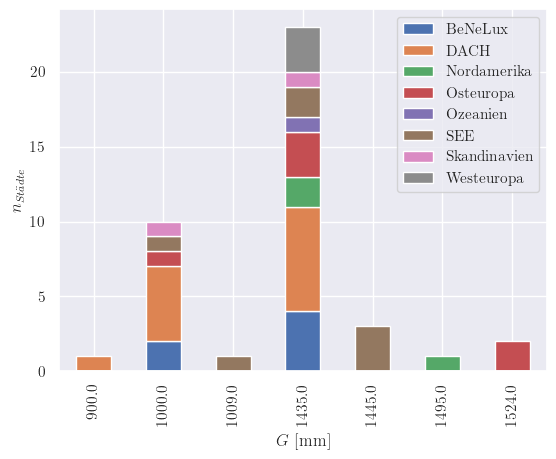

In [41]:
#g=sns.catplot(data=df_draw, x='gauge', y='Stadt', hue='region', kind='bar', hue_order=order)
#fig, ax = plt.subplots(1,1,figsize=(6.3,4.7))
g=result.plot(kind='bar', stacked=True,figsize=(6.3,4.7))
plt.legend(order)
plt.xlabel(da.COLUMN_NAMES_TEX['gauge'])
plt.ylabel(r'$n_{St\ddot{a}dte}$')
plt.savefig(RESULTS_DIR / 'Spurweiten_diagramm.png', dpi=600, bbox_inches='tight')

In [42]:
data[data['gauge']==1495]['Stadt']

1348    Toronto
1349    Toronto
1358    Toronto
1359    Toronto
1360    Toronto
1361    Toronto
1362    Toronto
1363    Toronto
1371    Toronto
1372    Toronto
1373    Toronto
1374    Toronto
Name: Stadt, dtype: object

### Lineare Regression

In [43]:
data[data['Stadt']=='Portland']

,line_name,line_number,from,to,distance,curvature,height_up,height_down,gauge,gtfs_first_stop_name,...,city,Country,ISO3166,Stadt,machine_readable,OSM-Name,Buffer_Width,region,rho_b,geometry
960,Streetcar A: Clockwise,A,Northwest Lovejoy & 9th,Northwest Lovejoy & 9th,9.896795,227.250354,26.271132,26.372175,1435.0,NW 9th & Lovejoy,...,portland,USA,US,Portland,portland,"Portland, OR, USA",83.226187,Nordamerika,0.262122,"LINESTRING (-122.68052 45.53008, -122.68048 45..."
961,Streetcar B: Counter-clockwise,B,Northwest 11th & Marshall,Northwest 11th & Marshall,10.192494,258.777770,24.037295,24.037295,1435.0,NW 11th & Marshall,...,portland,USA,US,Portland,portland,"Portland, OR, USA",83.226187,Nordamerika,0.255008,"LINESTRING (-122.68244 45.53091, -122.68244 45..."
962,Streetcar NS: Northwest 23rd & Marshall => Sou...,NS,Northwest 23rd & Marshall,South Lowell & Bond,6.239499,239.162750,25.162278,29.489549,1435.0,NW 23rd & Marshall,...,portland,USA,US,Portland,portland,"Portland, OR, USA",83.226187,Nordamerika,0.329921,"LINESTRING (-122.69867 45.53062, -122.69867 45..."
963,Streetcar NS: South Lowell & Bond => Northwest...,NS,South Lowell & Bond,Northwest 23rd & Marshall,6.414926,250.356223,33.047925,28.838991,1435.0,S Lowell & Bond,...,portland,USA,US,Portland,portland,"Portland, OR, USA",83.226187,Nordamerika,0.336571,"LINESTRING (-122.67138 45.49392, -122.6713 45...."


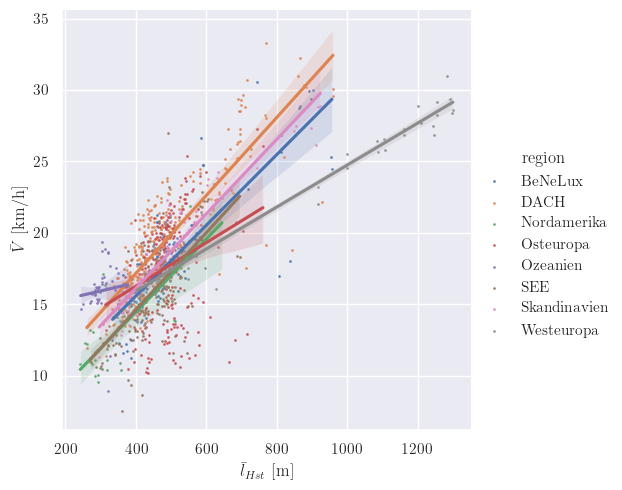

In [44]:
g=sns.lmplot(data=data.dropna(axis='index'), y='trip_speed', x='avg_dist', hue='region', hue_order=order, order=1, scatter_kws={'s':1})
#g._legend.set_title(title='Region')
plt.xlabel(da.COLUMN_NAMES_TEX['avg_dist'])
plt.ylabel(da.COLUMN_NAMES_TEX['trip_speed'])
#plt.xlim(0,1400)
#plt.ylim(0,35)


## Beschreibende Statistik Parameter

In [45]:
cols=list(da.COLUMN_NAMES_DE.keys())
data[data.columns.intersection(cols)].describe()

,curvature,height_up,height_down,gauge,trip_speed,avg_dist,rho_b
count,1012.000000,1012.000000,1012.000000,1012.000000,1012.000000,1012.000000,1012.000000
mean,146.223275,12.964650,13.014234,1368.415020,17.972222,485.591669,0.223775
std,66.533436,7.340290,7.481493,170.617462,4.130975,149.567188,0.077083
min,15.326808,3.291302,3.087368,900.000000,7.547809,242.124134,0.059673
25%,96.756185,8.192964,8.193079,1435.000000,15.212981,407.965972,0.162665
50%,136.265705,11.189700,11.176352,1435.000000,17.659457,462.277778,0.215789
75%,181.764309,15.681806,15.807120,1435.000000,20.165640,515.339624,0.278289
max,483.888051,89.217482,87.834918,1524.000000,33.255673,1299.915768,0.437954


In [52]:
df_region=data.groupby(by='region').aggregate(func=agg_func)
df_region['trip_speed']=data.groupby(by='region').apply(weighted_average, 'trip_speed', 'number_trips')
df_region

distance              number_trips    avg_dist     rho_b  \
                   mean          sum          sum        mean      mean   
region                                                                    
BeNeLux       10.750271  1279.282271      64906.0  506.097659  0.262696   
DACH          11.093683  3283.730254     165128.0  477.890733  0.243697   
Nordamerika   10.534837   273.905774      10104.0  363.460097  0.321594   
Osteuropa     12.835954  3208.988456      64705.0  490.058514  0.173031   
Ozeanien      14.537361   625.106509      37889.0  305.543480  0.234671   
SEE            9.387936  1661.664628      82127.0  446.296764  0.229312   
Skandinavien  13.035715   651.785761      51416.0  515.427634  0.218390   
Westeuropa    16.292967   830.941311      36132.0  781.737658  0.193090   

             machine_readable      Stadt ISO3166   gauge        region  \
                        count      first   first   first         first   
region                                                                   
BeNeLux                   119  Amsterdam      NL  1435.0       BeNeLux   
DACH                      296     Berlin      DE  1435.0          DACH   
Nordamerika                26   Portland      US  1435.0   Nordamerika   
Osteuropa                 250   Katowice      PL  1435.0     Osteuropa   
Ozeanien                   43  Melbourne      AU  1435.0      Ozeanien   
SEE                       177   Budapest      HU  1435.0           SEE   
Skandinavien               50   Göteborg      SE  1435.0  Skandinavien   
Westeuropa                 51   Bordeaux      FR  1435.0    Westeuropa   

             trip_speed  
                         
region                   
BeNeLux       18.116713  
DACH          17.356314  
Nordamerika   13.111626  
Osteuropa     18.276402  
Ozeanien      16.070961  
SEE           16.258076  
Skandinavien  19.300787  
Westeuropa    20.789240

## Get OSMNx Data (Entropy and Oritentations)

In [47]:
cities_df = pd.read_csv('./data/cities.csv', delimiter=';')
cities_dict=cities_df[['OSM-Name', 'RailModes']].set_index('OSM-Name').to_dict()['RailModes']

In [48]:
# list_to_get=list(data['OSM-Name'].unique())
# #list_to_get=['Vienna, Austria', 'Graz, Austria']
# entropy_street=[]
# entropy_tram=[]

# n = len(list_to_get)
# ncols = int(np.ceil(np.sqrt(n)))
# nrows = int(np.ceil(n / ncols))
# figsize = (ncols * 5 * 1.75, nrows * 5)
# #fig, axes = plt.subplots(nrows, ncols, figsize=figsize, subplot_kw={"projection": "polar"})

# fig=plt.figure(figsize=figsize)
# gs0 = gridspec.GridSpec(nrows, ncols, figure=fig)

# for grid, place in zip(gs0, sorted(list_to_get)):
#     print(ox.utils.ts(), place)

#     # get undirected graphs with edge bearing attributes
#     G_street = ox.graph.graph_from_place(place, network_type="all_public")
#     Gu_street = ox.bearing.add_edge_bearings(ox.convert.to_undirected(G_street))
#     entropy_street.append(ox.bearing.orientation_entropy(Gu_street))
#     #fig, ax = ox.plot.plot_orientation(Gu, ax=ax, title=place, area=True)

#     if pd.isna(cities_dict[place]) or cities_dict[place] == 'tram, light_rail':
#         filter_modes='["railway"~"tram|light_rail"]'
#     else:
#         filter_modes='["railway"~"'+cities_dict[place]+'"]'

#     G_tram = ox.graph.graph_from_place(place, custom_filter = filter_modes)
#     Gu_tram = ox.bearing.add_edge_bearings(ox.convert.to_undirected(G_tram))
#     entropy_tram.append(ox.bearing.orientation_entropy(Gu_tram))

#     gsi=grid.subgridspec(2, 2, height_ratios=[1,10])
#     axT = fig.add_subplot(gsi[0,:])
#     axT.set_axis_off()
#     axT.set_title(place, fontsize=22)
#     ax1 = fig.add_subplot(gsi[1,0], projection='polar')
#     ox.plot.plot_orientation(Gu_street, ax=ax1, title='Straßen', area=True, title_font={'size':18}, title_y=1.1)
#     ax2 = fig.add_subplot(gsi[1,1],projection='polar')
#     ox.plot.plot_orientation(Gu_tram, ax=ax2, title='Tram', area=True, color='r', title_font={'size':18}, title_y=1.1)

# fig.savefig(RESULTS_DIR / 'Orientations.png', dpi=600, bbox_inches='tight')

In [49]:
# entropy_tram
list_to_get=list(data['Stadt'].unique())
list_to_get

['Amsterdam',
 'Antwerpen',
 'Berlin',
 'Bordeaux',
 'Brandenburg a. d. Havel',
 'Brüssel',
 'Budapest',
 'Bukarest',
 'Den Haag',
 'Freiburg',
 'Gent',
 'Göteborg',
 'Graz',
 'Helsinki',
 'Innsbruck',
 'Katowice',
 'Köln',
 'Linz',
 'Lviv',
 'Lyon',
 'Mailand',
 'Manchester',
 'Melbourne',
 'München',
 'Portland',
 'Potsdam',
 'Prag',
 'Riga',
 'Rom',
 'Rotterdam',
 'San Francisco',
 'Sankt Petersburg',
 'Sofia',
 'Stuttgart',
 'Turin',
 'Toronto',
 'Ulm',
 'Warschau',
 'Wien',
 'Zagreb',
 'Zürich']

In [53]:
orientations=pd.read_csv(RESULTS_DIR / 'Orientations.csv')
#orientations.rename(axis='columns', inplace=True, mapper={0:'Stadt', 1:'H0_strasse', 2:'H0_tram'})
orientations

,Stadt,H0_strasse,H0_tram,phi_street,phi_tram
0,Amsterdam,3.493173,3.490362,0.080535,0.082987
1,Antwerpen,3.554713,3.556324,0.026045,0.024597
2,Berlin,3.571999,3.546233,0.010457,0.033647
3,Bordeaux,3.565893,3.442922,0.015978,0.123866
4,Brandenburg a. d. Havel,3.558548,3.491400,0.022597,0.082082
5,Brüssel,3.542412,3.370044,0.037062,0.184850
6,Budapest,3.527952,3.564070,0.049933,0.017622
7,Bukarest,3.572170,3.560040,0.010302,0.021254
8,Den Haag,3.295176,3.476335,0.245209,0.095171
9,Freiburg,3.537091,3.448254,0.041809,0.119318
